# **Predicting User Viewing Behavior for STC TV**


##Objectives

### Analyze User Viewing Behavior at STC TV

*   **Understand Viewing Patterns:** Gain insights into how users consume content.
*   **Build a Simple Prediction Model:** Develop a basic model to forecast future viewership numbers.

###**Read dataset**

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

#load dataset
dataFrame = pd.read_csv('/content/drive/MyDrive/ML_Predictive_Models/stc_TV_Data_Set_T2.csv')

dataFrame['date_'] = pd.to_datetime(dataFrame['date_']) # Convert 'date_' to datetime objects
dataFrame = dataFrame.sort_values(by='date_') # Sort by date for proper time series plotting

dataFrame.head()

Mounted at /content/drive


,Unnamed: 0,date_,Total_watch_time_in_houres
0,0,2018-01-01,1123.551944
1,1,2018-01-02,1000.129722
2,2,2018-01-03,881.924444
3,3,2018-01-04,782.669444
4,4,2018-01-05,1051.939444


In [2]:
#view size of data
dataFrame.shape
#view structure and data type
dataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Unnamed: 0                  86 non-null     int64         
 1   date_                       86 non-null     datetime64[ns]
 2   Total_watch_time_in_houres  86 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.1 KB


### **Exploratory Data Analysis (EDA)**

In [3]:
#check missing valuse
dataFrame.isnull().any()

,0
Unnamed: 0,False
date_,False
Total_watch_time_in_houres,False


In [4]:
#Summary statistics for numerical columns
dataFrame.describe()

,Unnamed: 0,date_,Total_watch_time_in_houres
count,86.000000,86,86.000000
mean,42.500000,2018-02-28 17:01:23.720930304,780.817926
min,0.000000,2018-01-01 00:00:00,562.124722
25%,21.250000,2018-01-30 06:00:00,707.709653
50%,42.500000,2018-02-28 12:00:00,763.181389
75%,63.750000,2018-03-29 18:00:00,840.985278
max,85.000000,2018-04-30 00:00:00,1123.551944
std,24.969982,NaN,122.992002


In [5]:
# Visualizing Viewing (date vs watch_time)
import plotly.express as px
fig = px.line(
    dataFrame,
    y="Total_watch_time_in_houres",
    title="Daily Watch Hours - STC Jawwy TV",
    labels={
        "Total_watch_time_in_houres": "Watch Hours",
        "date_": "Date"
    }
)
fig.show()

**Time Series Decomposition**

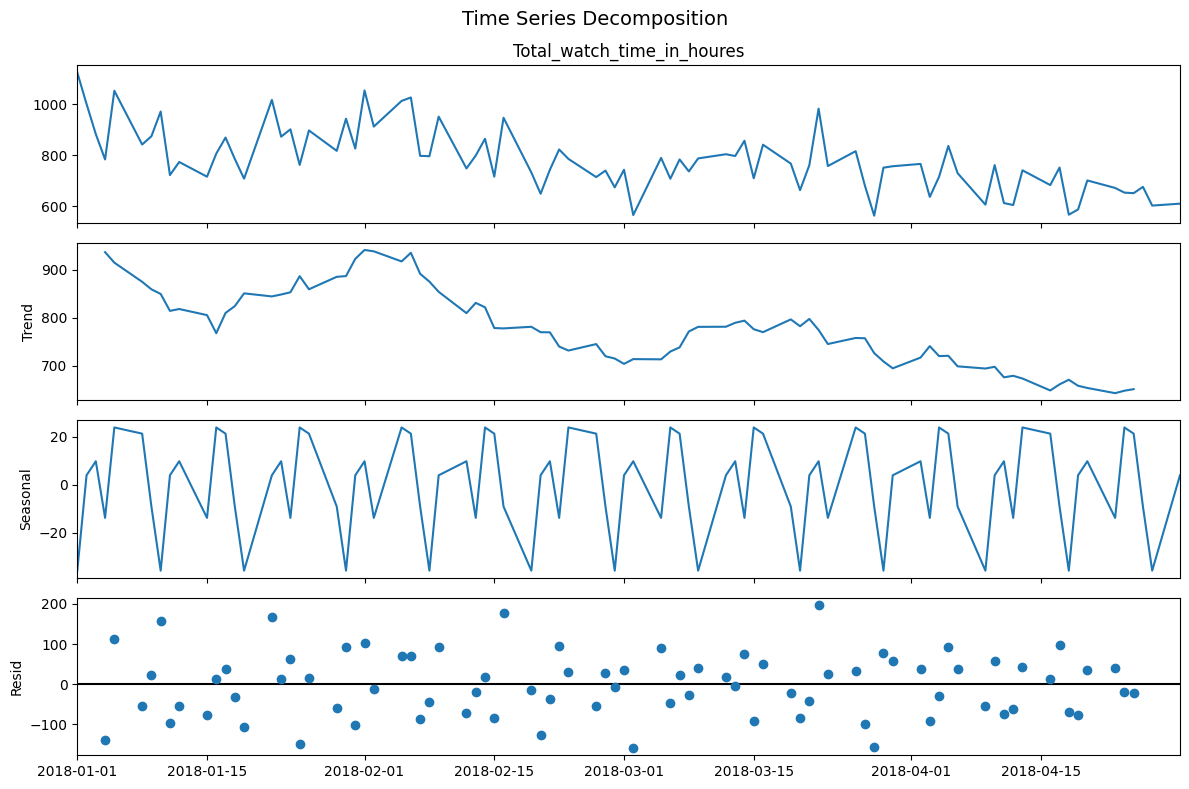

In [6]:
#Decomposition - Understand data components
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

#Decompose time series into its main components
decomposition = seasonal_decompose(dataFrame.set_index('date_')['Total_watch_time_in_houres'], model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

The decomposition separates the time series into trend, seasonal, and residual components.
This helps in understanding how the overall viewing behavior evolves over time and whether recurring weekly patterns exist in the data.

### **Data Preprocessing**



In [7]:
df = dataFrame.copy()

df = df[['date_', 'Total_watch_time_in_houres']].copy()

df.columns = ['ds', 'y']

print(df.head())
print(f"Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
print(f"Total number of days: {len(df)}")

          ds            y
0 2018-01-01  1123.551944
1 2018-01-02  1000.129722
2 2018-01-03   881.924444
3 2018-01-04   782.669444
4 2018-01-05  1051.939444
Date range: 2018-01-01 to 2018-04-30
Total number of days: 86


##**Model training**

In [8]:
import itertools

#Define all possible values for each parameter
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.05],
    'seasonality_prior_scale': [0.1, 0.5, 1.0, 5.0, 10.0],
    'weekly_seasonality': [True, False]
}

#Prepare a list containing all possible parameter combinations
all_params = [dict(zip(param_grid.keys(), v))
for v in itertools.product(*param_grid.values())]

print(f"Number of parameter combinations to test: {len(all_params)}")

Number of parameter combinations to test: 40


In [9]:
!pip install prophet

In [18]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

mae_scores = []
for params in all_params:
    model = Prophet(
        yearly_seasonality=False,
        daily_seasonality=True,
        **params
    )
    model.fit(df)

    df_cv = cross_validation(
        model,
        initial='30 days',
        period='7 days',
        horizon='14 days',
        disable_tqdm=True
    )
    df_p = performance_metrics(df_cv)
    mae = df_p['mae'].mean()

    mae_scores.append({
        'params': params,
        'mae': mae
    })

    print(f" changepoint={params['changepoint_prior_scale']} | "
          f"seasonality={params['seasonality_prior_scale']} | "
          f"weekly={params['weekly_seasonality']} | "
          f"MAE={mae:.2f}")

INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00
INFO:prophet:n_changepoints greater than number of observations. Using 19.


 changepoint=0.001 | seasonality=0.1 | weekly=True | MAE=78.13


INFO:prophet:n_changepoints greater than number of observations. Using 23.


 changepoint=0.001 | seasonality=0.1 | weekly=False | MAE=75.78


INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00
INFO:prophet:n_changepoints greater than number of observations. Using 19.


...

 changepoint=0.05 | seasonality=5.0 | weekly=False | MAE=75.87


INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00


 changepoint=0.05 | seasonality=10.0 | weekly=True | MAE=77.76


INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


 changepoint=0.05 | seasonality=10.0 | weekly=False | MAE=75.85


In [19]:
#Display results and select the best configuration
mae_result = pd.DataFrame(mae_scores)
mae_result = mae_result.sort_values(by='mae')

print("Best 5 configuration",mae_result.head())


best = mae_result.iloc[0]
print(f"\n Best configuration:")
print(f"   changepoint_prior_scale = {best['params']['changepoint_prior_scale']}")
print(f"   seasonality_prior_scale = {best['params']['seasonality_prior_scale']}")
print(f"   weekly_seasonality      = {best['params']['weekly_seasonality']}")
print(f"   MAE                     = {best['mae']:.2f}")

Best 5 configuration                                                params        mae
5   {'changepoint_prior_scale': 0.001, 'seasonalit...  75.114699
15  {'changepoint_prior_scale': 0.01, 'seasonality...  75.418309
35  {'changepoint_prior_scale': 0.05, 'seasonality...  75.744699
1   {'changepoint_prior_scale': 0.001, 'seasonalit...  75.784288
11  {'changepoint_prior_scale': 0.01, 'seasonality...  75.807755

 Best configuration:
   changepoint_prior_scale = 0.001
   seasonality_prior_scale = 1.0
   weekly_seasonality      = False
   MAE                     = 75.11


In [20]:
import plotly.graph_objects as go
from prophet import Prophet

#Build the final model using the best parameters
model = Prophet(
    yearly_seasonality=False,
    daily_seasonality=True,
    changepoint_prior_scale=best['params']['changepoint_prior_scale'],
    seasonality_prior_scale=best['params']['seasonality_prior_scale'],
    weekly_seasonality=best['params']['weekly_seasonality']
)
model.fit(df)

# Generate a future dataframe for the next 60 days
future = model.make_future_dataframe(periods=60)
# Make predictions using the model on the future dataframe
forecast = model.predict(future)

In [21]:
import plotly.graph_objects as go
fig2 = go.Figure()

# Historical data (actual values)
fig2.add_trace(go.Scatter(
    x=df['ds'], y=df['y'],
    mode='lines', name='Actual Watch Hours',
    line=dict(color='blue', width=2)
))

# Forecasted values (prediction)
fig2.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    mode='lines', name='Forecast',
    line=dict(color='red', width=2, dash='dash')
))

# Confidence interval
fig2.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(255,0,0,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))

fig2.update_layout(
    title='Watch Hours Forecast - Next Two Months',
    xaxis_title='Date',
    yaxis_title='Watch Hours'
)

fig2.show()

In [27]:
#Prophet components
from prophet.plot import plot_components_plotly

fig = plot_components_plotly(model, forecast)
fig.update_layout(title='Prophet model components', height=500)

fig.show()

Although the initial EDA and time series decomposition suggested a recurring weekly pattern, the hyperparameter tuning (based on proper out-of-sample cross-validation) selected a configuration with weekly_seasonality=False, as it produced a lower validation error.
This suggests that with only 86 days of data (~12 weeks), there isn't enough historical depth for the model to reliably estimate a stable weekly effect — enabling it added noise rather than signal. This is a good example of why validation-based selection can override an assumption that seemed reasonable during EDA.

It is worth noting that the forecast line appears smooth compared to the highly
fluctuating actual values. This is expected behavior rather than a limitation:
the daily fluctuations in the actual data are largely random noise, while the
forecast represents the underlying trend and weekly seasonality signal only.
A model that reproduced the same day-to-day noise pattern from historical data
would be overfitting, since that specific noise is not expected to repeat
identically in the future.

One caution to keep in mind is the length of the forecast horizon (60 days)
relative to the historical data available (86 days). Since the trend is
extrapolated linearly into the future, longer horizons carry higher risk of
diverging from realistic values, which is also reflected in the widening
confidence interval over time.

**Model evaluation**

In [23]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv_final = cross_validation(
    model,
    initial='30 days',
    period='7 days',
    horizon='14 days',
    disable_tqdm=True
)
df_p_final = performance_metrics(df_cv_final)

mae = df_p_final['mae'].mean()
rmse = df_p_final['rmse'].mean()

print("Model Performance (out-of-sample):")
print(f"MAE (Mean Absolute Error): {mae:.2f} hours")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} hours")

INFO:prophet:Making 11 forecasts with cutoffs between 2018-02-05 00:00:00 and 2018-04-16 00:00:00
INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


Model Performance (out-of-sample):
MAE (Mean Absolute Error): 75.11 hours
RMSE (Root Mean Squared Error): 92.61 hours


The MAE indicates that the model's predictions differ from the actual values by approximately 75 hours on average, based on out-of-sample cross-validation.
The RMSE (92.61 hours) is higher because it penalizes larger prediction errors more strongly.
Considering the variability in the dataset and the limited historical data (86 days), this error level is acceptable for a short time-series dataset.

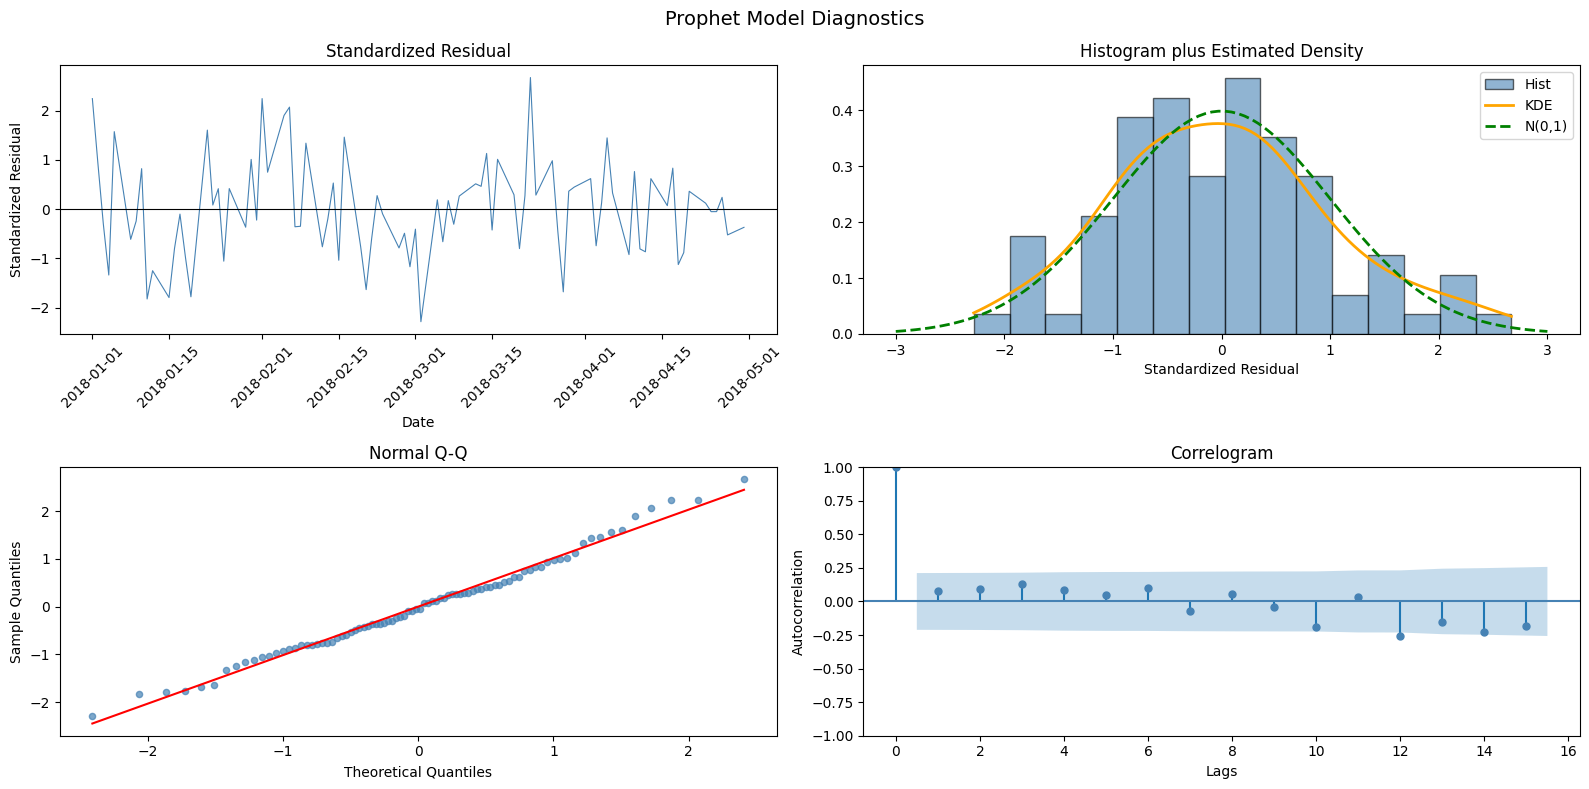

In [24]:
# Prophet Diagnostics
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

# Residuals
historical  = forecast[forecast['ds'].isin(df['ds'])]
residuals   = df['y'].values - historical['yhat'].values
std_resid   = (residuals - residuals.mean()) / residuals.std()

fig = plt.figure(figsize=(16, 8))
fig.suptitle('Prophet Model Diagnostics', fontsize=14)
gs  = gridspec.GridSpec(2, 2, figure=fig)

# Standardized Residual
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['ds'], std_resid, color='steelblue', linewidth=0.8)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_title('Standardized Residual')
ax1.set_xlabel('Date')
ax1.set_ylabel('Standardized Residual')
ax1.tick_params(axis='x', rotation=45)



# Histogram + KDE
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(std_resid, bins=15, density=True,
         color='steelblue', alpha=0.6,
         edgecolor='black', label='Hist')

# KDE
from scipy.stats import gaussian_kde
kde_x = np.linspace(std_resid.min(), std_resid.max(), 100)
kde   = gaussian_kde(std_resid)
ax2.plot(kde_x, kde(kde_x), color='orange', linewidth=2, label='KDE')

# Normal curve
norm_x = np.linspace(-3, 3, 100)
ax2.plot(norm_x, stats.norm.pdf(norm_x),
         color='green', linewidth=2, linestyle='--', label='N(0,1)')

ax2.set_title('Histogram plus Estimated Density')
ax2.set_xlabel('Standardized Residual')
ax2.legend()

# Normal Q-Q
ax3 = fig.add_subplot(gs[1, 0])
(osm, osr), (slope, intercept, r) = stats.probplot(std_resid, dist='norm')
ax3.scatter(osm, osr, color='steelblue', s=20, alpha=0.7)
ax3.plot(osm, slope * np.array(osm) + intercept,
         color='red', linewidth=1.5)
ax3.set_title('Normal Q-Q')
ax3.set_xlabel('Theoretical Quantiles')
ax3.set_ylabel('Sample Quantiles')


# Correlogram
ax4 = fig.add_subplot(gs[1, 1])
sm.graphics.tsa.plot_acf(
    std_resid,
    lags=15,
    ax=ax4,
    color='steelblue',
    title='Correlogram'
)
ax4.set_xlabel('Lags')
ax4.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()


The residual plot shows that most errors fluctuate around zero, suggesting no strong bias in the model predictions.
The histogram and KDE indicate that the residuals follow a distribution close to normal.
The Q-Q plot further confirms that most residuals align with the expected normal distribution, with minor deviations at the extremes.
Finally, the correlogram shows that most autocorrelation values lie within the confidence interval, indicating that the residuals do not exhibit strong temporal dependence.

In [25]:
# Filter only future dates
future_only = forecast[forecast['ds'] > df['ds'].max()]

# Find the day with the highest predicted watch hours
peak_day = future_only.loc[future_only['yhat'].idxmax()]
print(f"Highest Watch Day: {peak_day['ds'].date()}")
print(f"Expected Watch Hours: {peak_day['yhat']:.0f}")

# Find the day with the lowest predicted watch hours
lowest_day = future_only.loc[future_only['yhat'].idxmin()]
print(f"Lowest Watch Day: {lowest_day['ds'].date()}")
print(f"Expected Watch Hours: {lowest_day['yhat']:.0f}")

Highest Watch Day: 2018-05-01
Expected Watch Hours: 641
Lowest Watch Day: 2018-06-29
Expected Watch Hours: 507
